In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.sparse import csc_matrix, eye, diags
from scipy.sparse.linalg import spsolve

In [5]:

import numpy as np
import pandas as pd


def parse_csv(file_input):
    """파일 경로(str)나 Streamlit UploadedFile 객체 모두 처리 가능한 파싱 함수"""
    try:
        # 1. Streamlit UploadedFile인 경우 또는 일반 경로인 경우 자동 읽기
        # pd.read_csv는 파일 경로 문자열뿐만 아니라 Streamlit의 UploadedFile 객체도 직접 읽을 수 있습니다!
        raw_df = pd.read_csv(
            file_input,
            header=None,
            sep=None,
            engine="python",
            on_bad_lines="skip",
        )
    except Exception:
        # 혹시 위에서 실패 시 공백 구분자로 재시도
        # (UploadedFile 객체라면 이전에 읽다가 포인터가 끝으로 갔을 수 있으므로 seek(0) 처리)
        if hasattr(file_input, "seek"):
            file_input.seek(0)

        raw_df = pd.read_csv(
            file_input,
            header=None,
            sep=r"\s+",
            engine="python",
            on_bad_lines="skip",
        )

    numeric_df = raw_df.apply(pd.to_numeric, errors="coerce")
    wn_col_idx = None

    # 파수(Wavenumber) 열 탐색
    for col in numeric_df.columns:
        col_data = numeric_df[col].dropna().values
        if len(col_data) < 50:
            continue

        min_val, max_val = col_data.min(), col_data.max()

        # 파수 범위 조건 (100~500 출발, 2000~4500 종료)
        if (min_val >= 100 and min_val <= 500) and (
            max_val >= 2000 and max_val <= 4500
        ):
            diffs = np.diff(col_data)
            if np.mean(diffs > 0) > 0.95:  # 오름차순
                wn_col_idx = col
                break

    if wn_col_idx is None:
        raise ValueError(
            f"[{file_input}] 파일에서 Wavenumber 열을 찾지 못했습니다."
        )

    intensity_col_idx = wn_col_idx + 1

    target_df = numeric_df[[wn_col_idx, intensity_col_idx]].dropna()
    target_df.columns = ["Wavenumber", "Intensity"]
    target_df = target_df.reset_index(drop=True)

    # 데이터프레임만 딱 반환!
    return target_df

In [ ]:
# -------------------------------------------------------------
#  3. 파수 범위 정수화 (예: 최소 파수부터 최대 파수까지 1 cm^-1 간격)
# -------------------------------------------------------------
def wavenumber_to_integer(wavenumber):
    """파수 범위를 정수화하여 1 cm^-1 간격으로 변환"""
    wn_min = int(np.ceil(wavenumber.min()))
    wn_max = int(np.floor(wavenumber.max()))
    return np.arange(wn_min, wn_max + 1)  # 정수 파수 축 생성 (예: 240, 241, ..., 3200)
# ------------------------------------------------
#  4. 내삽 (1D Interpolation)
# -------------------------------------------------------------
# 원래 wavenumber 축에서 정수 wn_int 축으로 스펙트럼 보정
def interpolate_spectra(wavenumber, spectra, wn_int):
    """1D 내삽을 통해 스펙트럼을 정수 파수 축으로 변환"""
    interp_func = interp1d(wavenumber, spectra, axis=0, kind='linear', fill_value='extrapolate')
    return interp_func(wn_int)
# -------------------------------------------------------------
#  5. DB와 공통 범위만 추출 (예: DB 범위가 400 ~ 3000 cm^-1 인 경우)
# -------------------------------------------------------------
def extract_common_range(wn_int, spectra_interp, db_min=238, db_max=3200):
    """DB와 공통 범위만 추출"""
    mask = (wn_int >= db_min) & (wn_int <= db_max)
    return wn_int[mask], spectra_interp[mask, :]

# -------------------------------------------------------------
#  6. 베이스라인 교정 (ALS: Asymmetric Least Squares)
# -------------------------------------------------------------
def baseline_als(y, lam=1e6, p=0.001, niter=10):
    """ALS 베이스라인 교정 함수 (MATLAB ALS 알고리즘과 동일)"""
    L = len(y)
    D = diags([1, -2, 1], [0, -1, -2], shape=(L, L-2))
    w = np.ones(L)
    for _ in range(niter):
        W = diags([w], [0])
        Z = W + lam * D.dot(D.T)
        z = spsolve(Z, w * y)
        w = p * (y > z) + (1 - p) * (y <= z)
    return z

# 각 샘플(열)별로 ALS 베이스라인 차감
def baseline_correction(spectra_common):
    """각 샘플별로 ALS 베이스라인 교정 수행"""
    num_wave, num_samples = spectra_common.shape
    spectra_bc = np.zeros((num_wave, num_samples))
    for i in range(num_samples):
        baseline = baseline_als(spectra_common[:, i], lam=1e6, p=0.001)
        spectra_bc[:, i] = spectra_common[:, i] - baseline
    return spectra_bc


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse.linalg import spsolve

def baseline_arpls(y, lam=1e4, ratio=0.05, itermax=10):
    """
    ArPLS (Asymmetrically Reweighted Penalized Least Squares)
    라만 스펙트럼의 형상을 보존하며 형광(Fluorescence) 베이스라인을 효과적으로 제거합니다.
    
    Parameters:
    - y: 원본 스펙트럼 강도 (1D array)
    - lam: smoothness 파라미터 (클수록 베이스라인이 매끄러워짐, 보통 1e3~1e7)
    - ratio: 수렴 조건
    """
    N = len(y)
    D = sparse.eye(N, format='csr')
    D = D[1:] - D[:-1]
    D = D[1:] - D[:-1]
    
    H = lam * D.T * D
    w = np.ones(N)
    
    while itermax > 0:
        W = sparse.diags(w, 0, shape=(N, N))
        Z = W + H
        z = spsolve(Z, w * y)
        d = y - z
        dn = d[d < 0]
        if len(dn) == 0:
            break
        m = np.mean(dn)
        s = np.std(dn)
        
        wt = 1 / (1 + np.exp(2 * (d - (2 * s - m)) / s))
        if np.linalg.norm(w - wt) / np.linalg.norm(w) < ratio:
            break
        w = wt
        itermax -= 1
        
    return z


def plot_baseline_correction(x_wavenumber, y_raw, lam=1e4):
    """
    원본 스펙트럼, 추정된 베이스라인, 보정 후 스펙트럼을 함께 시각화합니다.
    """
    # 1. 베이스라인 추정 및 제거
    baseline = baseline_arpls(y_raw, lam=lam)
    y_corrected = y_raw - baseline
    
    # 2. 시각화
    plt.figure(figsize=(10, 5))
    
    # 원본 vs 추정 베이스라인
    plt.subplot(1, 2, 1)
    plt.plot(x_wavenumber, y_raw, label='Raw Spectrum', color='gray', alpha=0.7)
    plt.plot(x_wavenumber, baseline, label='Estimated Baseline', color='red', linestyle='--')
    plt.xlabel('Wavenumber (cm⁻¹)')
    plt.ylabel('Intensity')
    plt.title('Raw Spectrum & Baseline')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 베이스라인 제거 후
    plt.subplot(1, 2, 2)
    plt.plot(x_wavenumber, y_corrected, label='Baseline Corrected', color='blue')
    plt.xlabel('Wavenumber (cm⁻¹)')
    plt.ylabel('Intensity')
    plt.title('After Baseline Correction')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return y_corrected


/var/folders/w3/92n51zfj1fdg692kb505y15w0000gp/T/ipykernel_1576/2162362861.py:35: RuntimeWarning: overflow encountered in exp
  wt = 1 / (1 + np.exp(2 * (d - (2 * s - m)) / s))


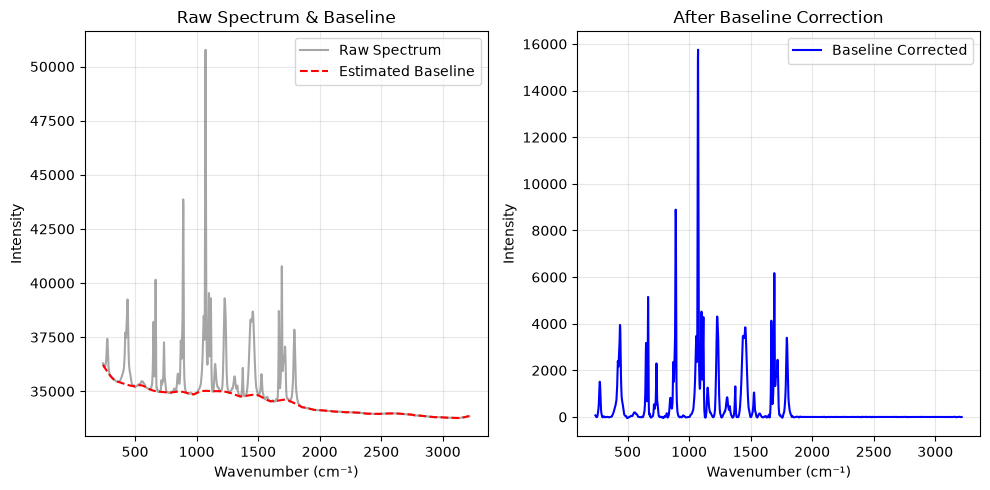

In [ ]:
csv_file_path = "data/test.csv"  # CSV 파일 경로를 지정하세요
# CSV 파일에서 데이터 읽기
data_df = parse_csv(csv_file_path)
x_wavenumber = data_df['Wavenumber'].values
y_raw = data_df['Intensity'].values
y_corrected = plot_baseline_correction(x_wavenumber, y_raw, lam=1e4)

In [21]:

# -------------------------------------------------------------
#  7. 정규화 (SNV: Standard Normal Variate)
# -------------------------------------------------------------
def snv_normalization(spectra_bc):
    """SNV 정규화 함수"""
    num_wave, num_samples = spectra_bc.shape
    target_snv = np.zeros((num_wave, num_samples))
    for i in range(num_samples):
        m = np.mean(spectra_bc[:, i])
        s = np.std(spectra_bc[:, i])
        if s == 0:
            s = np.finfo(float).eps  # 표준편차가 0인 경우 작은 값으로 대체
        target_snv[:, i] = (spectra_bc[:, i] - m) / s
    return target_snv

In [22]:
#-------------------------------------------------------------
# 그래프 그리기
#-------------------------------------------------------------
def plot_spectra(wn_common, target_snv):
    """처리된 스펙트럼 그래프 그리기"""
    plt.figure(figsize=(10, 5))
    plt.plot(wn_common, target_snv)
    plt.grid(True)
    plt.xlabel('Wavenumber (cm$^{-1}$)')
    plt.ylabel('SNV Intensity')
    plt.title('Processed & SNV Normalized Spectra')
    plt.show()


In [23]:
import numpy as np
import pandas as pd


def preprocess_file(input_file, db_min=180, db_max=4000):
    """파일 경로를 받아 파싱 -> 전처리 -> 시각화 -> 데이터 반환"""

    # 1. 파싱 (target_df만 가져옴)
    target_df = parse_csv(input_file)

    wavenumber = target_df["Wavenumber"].values
    spectra = target_df["Intensity"].values.reshape(-1, 1)

    # 2. 파수 범위 안전성 체크
    actual_min = int(np.ceil(wavenumber.min()))
    actual_max = int(np.floor(wavenumber.max()))

    valid_min = max(db_min, actual_min)
    valid_max = min(db_max, actual_max)

    # 3. 정수화 및 내삽 (Interpolation)
    wn_int = wavenumber_to_integer(wavenumber)
    spectra_interp = interpolate_spectra(wavenumber, spectra, wn_int)

    # 4. 공통 파수 범위 추출
    wn_common, spectra_common = extract_common_range(
        wn_int, spectra_interp, db_min=valid_min, db_max=valid_max
    )

    # 5. 베이스라인 교정 (ALS) & 정규화 (SNV)
    spectra_bc = baseline_correction(spectra_common)
    target_snv = snv_normalization(spectra_bc)

    # 6. 그래프 시각화
    plot_spectra(wn_common, target_snv)

    # 7. 최종 결과 데이터만 2개 반환
    return wn_common, target_snv

/var/folders/w3/92n51zfj1fdg692kb505y15w0000gp/T/ipykernel_1576/2656540695.py:31: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  D = diags([1, -2, 1], [0, -1, -2], shape=(L, L-2))
/var/folders/w3/92n51zfj1fdg692kb505y15w0000gp/T/ipykernel_1576/2656540695.py:36: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


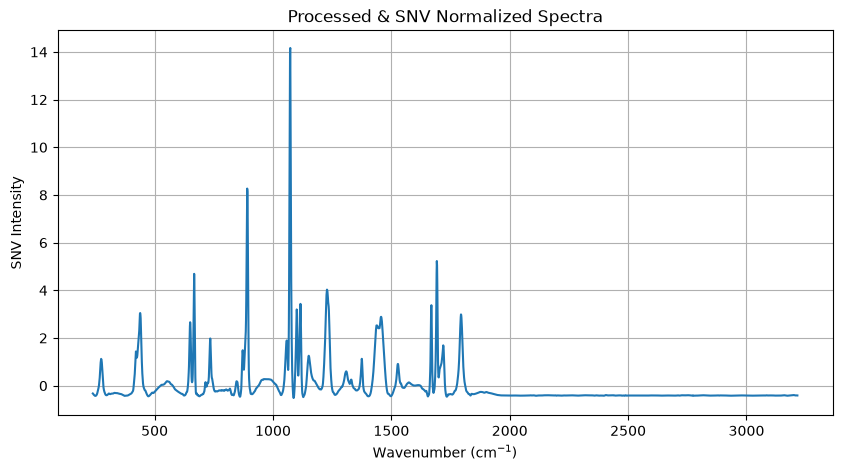

In [29]:
# 🔥 함수 실행 (data/test.csv 경로를 본인 파일 경로로 맞추세요)
wn_common, target_snv = preprocess_file("data/test3.csv")